# Pipeline 4: Donor Segmentation (K-Means Clustering)

## 1. Problem Framing

**Business question:** Can we identify distinct donor personas based on giving 
behavior so the organization can tailor outreach, retention strategies, and 
communication to each group?

**Who cares:** The Executive Director and anyone managing donor relationships. 
The case explicitly states the org "loses donors and doesn't always understand 
why" and wants to "personalize outreach without a dedicated marketing team." 
Segmentation directly solves this — instead of sending the same message to 
every donor, staff can send targeted messages to each persona.

**Approach: Unsupervised (Clustering)**
This is an unsupervised learning problem. We do not have a predefined target 
variable — we are discovering natural groupings in the data. Unlike our other 
pipelines, there is no train/test split because we are not predicting an outcome 
for new data; we are describing structure in existing data.

This is appropriate here because the organization does not know how many donor 
types exist or what defines them. Clustering lets the data reveal the natural 
segments rather than imposing predetermined categories.

**Framework: RFM Analysis**
We use the well-established RFM framework from marketing analytics:
- **Recency:** How recently did the donor last give?
- **Frequency:** How many times have they given?
- **Monetary:** What is their total lifetime giving value?

RFM is the gold standard for donor and customer segmentation because these 
three dimensions capture the most important behavioral signals for retention 
and growth.

**Success metric:** Silhouette score (measures how well-separated clusters are) 
and elbow curve (justifies the number of clusters). Cluster interpretability 
and actionability matter as much as statistical metrics here — a cluster that 
staff can actually act on is more valuable than a marginally better silhouette 
score.


## 2. Data Acquisition, Preparation & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
import joblib
import warnings
warnings.filterwarnings('ignore')

CSV_DIR = '../lighthouse_csv_v7/lighthouse_csv_v7/'

supporters = pd.read_csv(CSV_DIR + 'supporters.csv')
donations = pd.read_csv(CSV_DIR + 'donations.csv')

print("Supporters shape:", supporters.shape)
print("Donations shape:", donations.shape)

print("\nDonation types:")
print(donations['donation_type'].value_counts())

print("\nAmount column stats (monetary only):")
monetary = donations[donations['donation_type'] == 'Monetary']
print(monetary['amount'].describe())

print("\nSupporter status:")
print(supporters['status'].value_counts())

Supporters shape: (60, 15)
Donations shape: (420, 13)

Donation types:
donation_type
Monetary       234
InKind          98
Time            46
SocialMedia     23
Skills          19
Name: count, dtype: int64

Amount column stats (monetary only):
count     234.00000
mean     1028.73735
std       767.59608
min       250.00000
25%       482.50750
50%       819.63000
75%      1333.15500
max      6481.54000
Name: amount, dtype: float64

Supporter status:
status
Active      45
Inactive    15
Name: count, dtype: int64


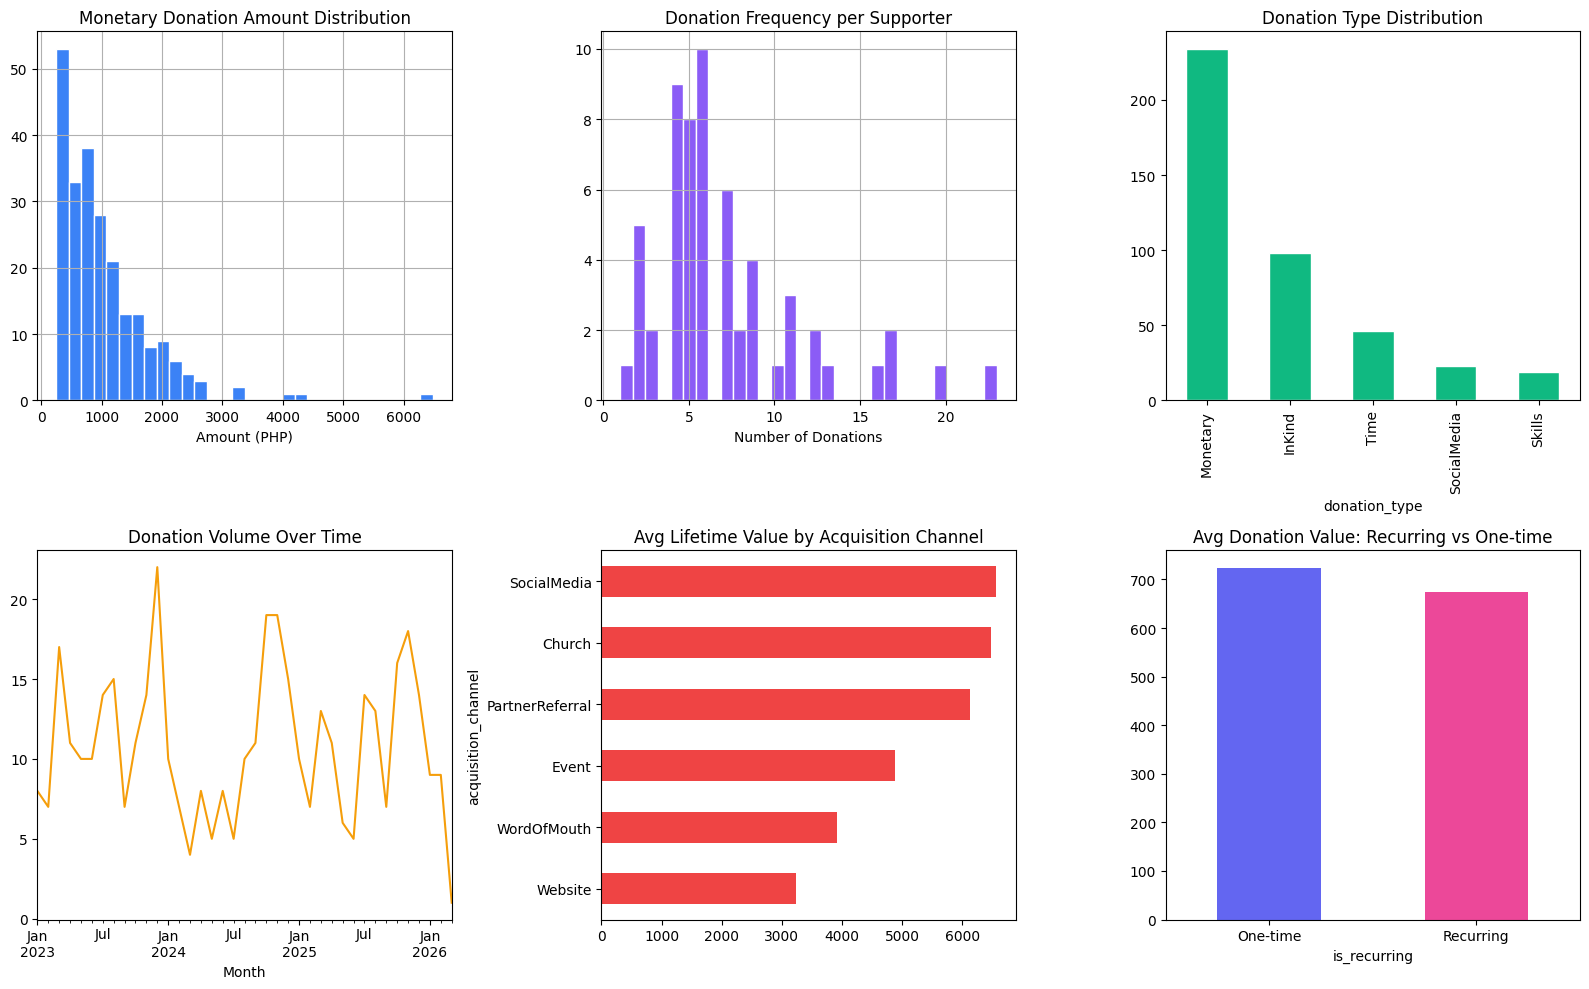

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Donation amount distribution
monetary['amount'].hist(bins=30, ax=axes[0,0], color='#3b82f6', edgecolor='white')
axes[0,0].set_title('Monetary Donation Amount Distribution')
axes[0,0].set_xlabel('Amount (PHP)')

# Donation frequency per supporter
freq = donations.groupby('supporter_id').size()
freq.hist(bins=30, ax=axes[0,1], color='#8b5cf6', edgecolor='white')
axes[0,1].set_title('Donation Frequency per Supporter')
axes[0,1].set_xlabel('Number of Donations')

# Donation type mix
donations['donation_type'].value_counts().plot(
    kind='bar', ax=axes[0,2], color='#10b981', edgecolor='white'
)
axes[0,2].set_title('Donation Type Distribution')

# Donations over time
donations['donation_date'] = pd.to_datetime(donations['donation_date'])
donations['year_month'] = donations['donation_date'].dt.to_period('M')
donations.groupby('year_month').size().plot(
    ax=axes[1,0], color='#f59e0b'
)
axes[1,0].set_title('Donation Volume Over Time')
axes[1,0].set_xlabel('Month')

# Total value by acquisition channel
channel_value = supporters.merge(
    donations.groupby('supporter_id')['estimated_value'].sum().reset_index(),
    on='supporter_id', how='left'
)
channel_value.groupby('acquisition_channel')['estimated_value'].mean().sort_values().plot(
    kind='barh', ax=axes[1,1], color='#ef4444'
)
axes[1,1].set_title('Avg Lifetime Value by Acquisition Channel')

# Recurring vs non-recurring
donations.groupby('is_recurring')['estimated_value'].mean().plot(
    kind='bar', ax=axes[1,2], color=['#6366f1','#ec4899']
)
axes[1,2].set_title('Avg Donation Value: Recurring vs One-time')
axes[1,2].set_xticklabels(['One-time', 'Recurring'], rotation=0)

plt.tight_layout()
plt.savefig('segmentation_eda.png')
plt.show()

RFM dataset shape: (59, 11)

RFM summary:
       recency  frequency  monetary
count     59.0       59.0      59.0
mean     185.5        7.1    4978.1
std      186.9        4.5    3542.9
min        0.0        1.0      27.1
25%       59.5        4.0    2212.0
50%      118.0        6.0    3976.0
75%      267.5        9.0    6951.2
max      797.0       23.0   14240.3


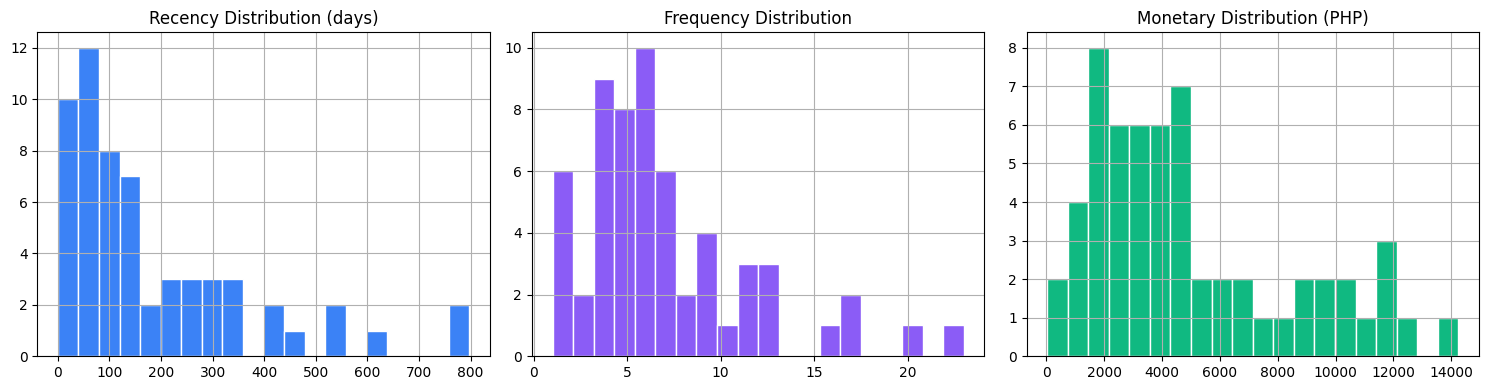

In [3]:
donations['donation_date'] = pd.to_datetime(donations['donation_date'])
reference_date = donations['donation_date'].max()

# Use estimated_value for all donation types (not just monetary amount)
# This captures volunteers, in-kind donors etc. with their estimated contribution
rfm = donations.groupby('supporter_id').agg(
    recency=('donation_date', lambda x: (reference_date - x.max()).days),
    frequency=('donation_id', 'count'),
    monetary=('estimated_value', lambda x: x.fillna(0).sum()),
).reset_index()

# Add extra behavioral features
extra = donations.groupby('supporter_id').agg(
    is_recurring=('is_recurring', 'max'),
    num_campaigns=('campaign_name', 'nunique'),
    num_donation_types=('donation_type', 'nunique'),
).reset_index()

rfm = rfm.merge(extra, on='supporter_id', how='left')
rfm['is_recurring'] = rfm['is_recurring'].fillna(False).astype(int)
rfm = rfm.fillna(0)

# Merge with supporter info
rfm = rfm.merge(
    supporters[['supporter_id', 'status', 'acquisition_channel',
                'supporter_type', 'relationship_type']],
    on='supporter_id', how='left'
)

print("RFM dataset shape:", rfm.shape)
print("\nRFM summary:")
print(rfm[['recency','frequency','monetary']].describe().round(1))

# Check for outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
rfm['recency'].hist(bins=20, ax=axes[0], color='#3b82f6', edgecolor='white')
axes[0].set_title('Recency Distribution (days)')
rfm['frequency'].hist(bins=20, ax=axes[1], color='#8b5cf6', edgecolor='white')
axes[1].set_title('Frequency Distribution')
rfm['monetary'].hist(bins=20, ax=axes[2], color='#10b981', edgecolor='white')
axes[2].set_title('Monetary Distribution (PHP)')
plt.tight_layout()
plt.savefig('rfm_distributions.png')
plt.show()

## 3. Modeling & Feature Selection

We use K-Means clustering on RFM features. Before fitting we must:
1. Scale features (K-Means is distance-based so unscaled features dominate)
2. Determine optimal k using the elbow curve and silhouette scores
3. Interpret and name each cluster based on its centroid profile

**Feature selection rationale:** We use Recency, Frequency, and Monetary as 
our core features because they are the most universally validated predictors 
of donor retention and value. We add is_recurring and num_campaigns as 
supplementary features because they capture commitment signals beyond 
raw giving history.

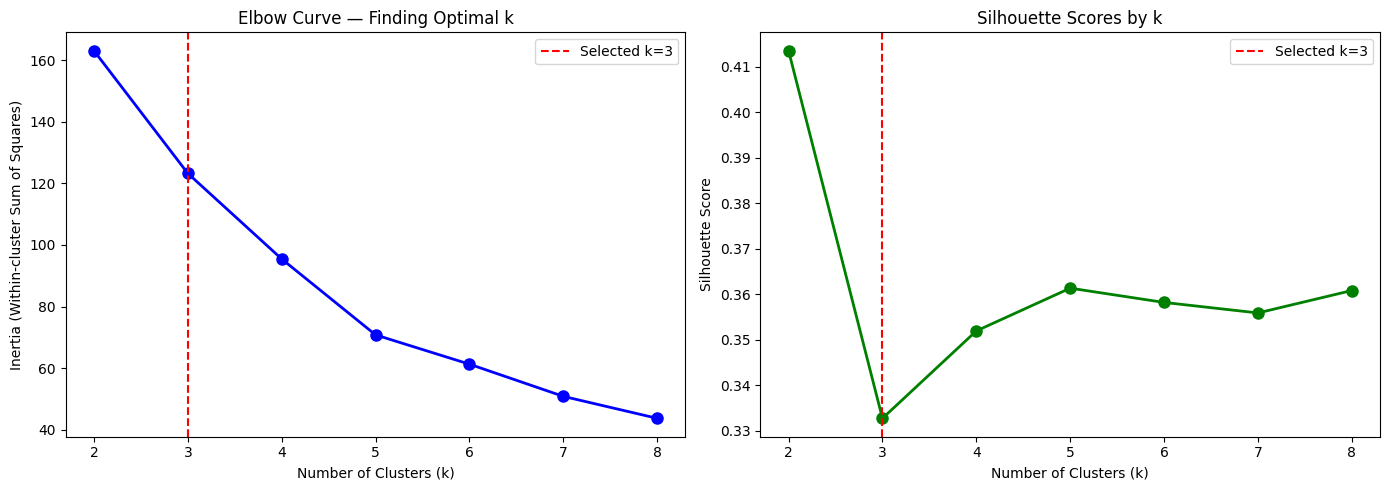

Silhouette scores by k:
  k=2: 0.413
  k=3: 0.333
  k=4: 0.352
  k=5: 0.361
  k=6: 0.358
  k=7: 0.356
  k=8: 0.361

Best k by silhouette: 2
We will use k=3 for interpretability and business actionability.


In [4]:
# Scale RFM features
cluster_features = ['recency', 'frequency', 'monetary', 
                    'is_recurring', 'num_campaigns']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm[cluster_features].fillna(0))

# Elbow curve
inertias = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-cluster Sum of Squares)')
axes[0].set_title('Elbow Curve — Finding Optimal k')
axes[0].axvline(x=3, color='red', linestyle='--', label='Selected k=3')
axes[0].legend()

# Silhouette scores
axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Scores by k')
axes[1].axvline(x=3, color='red', linestyle='--', label='Selected k=3')
axes[1].legend()

plt.tight_layout()
plt.savefig('segmentation_elbow.png')
plt.show()

print("Silhouette scores by k:")
for k, score in zip(k_range, silhouette_scores):
    print(f"  k={k}: {score:.3f}")

best_k = k_range[np.argmax(silhouette_scores)]
print(f"\nBest k by silhouette: {best_k}")
print("We will use k=3 for interpretability and business actionability.")

In [5]:
# Fit final model with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['cluster'] = kmeans.fit_predict(X_scaled)

final_silhouette = silhouette_score(X_scaled, rfm['cluster'])
print(f"Final silhouette score (k=3): {final_silhouette:.3f}")

# Cluster summary
cluster_summary = rfm.groupby('cluster').agg(
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    pct_recurring=('is_recurring', 'mean'),
    avg_campaigns=('num_campaigns', 'mean'),
    count=('supporter_id', 'count')
).round(2)

print("\n=== CLUSTER PROFILES ===")
print(cluster_summary)

# Name clusters based on their profiles
# Sort by monetary value to assign names consistently
cluster_monetary = rfm.groupby('cluster')['monetary'].mean().sort_values(ascending=False)
cluster_names = {}
rank_to_name = {0: 'Champions', 1: 'At-Risk Donors', 2: 'New/Occasional Donors'}
for rank, (cluster_id, _) in enumerate(cluster_monetary.items()):
    cluster_names[cluster_id] = rank_to_name[rank]

rfm['persona'] = rfm['cluster'].map(cluster_names)

print("\n=== DONOR PERSONAS ===")
persona_summary = rfm.groupby('persona').agg(
    count=('supporter_id', 'count'),
    avg_recency_days=('recency', 'mean'),
    avg_donations=('frequency', 'mean'),
    avg_lifetime_value=('monetary', 'mean'),
    pct_recurring=('is_recurring', 'mean'),
).round(1)
print(persona_summary)

Final silhouette score (k=3): 0.333

=== CLUSTER PROFILES ===
         avg_recency  avg_frequency  avg_monetary  pct_recurring  \
cluster                                                            
0             130.38           5.73       4210.51           0.14   
1             524.00           3.60       1866.34           0.10   
2              73.58          14.33       9937.97           1.00   

         avg_campaigns  count  
cluster                        
0                 1.38     37  
1                 1.50     10  
2                 2.75     12  

=== DONOR PERSONAS ===
                       count  avg_recency_days  avg_donations  \
persona                                                         
At-Risk Donors            37             130.4            5.7   
Champions                 12              73.6           14.3   
New/Occasional Donors     10             524.0            3.6   

                       avg_lifetime_value  pct_recurring  
persona                     

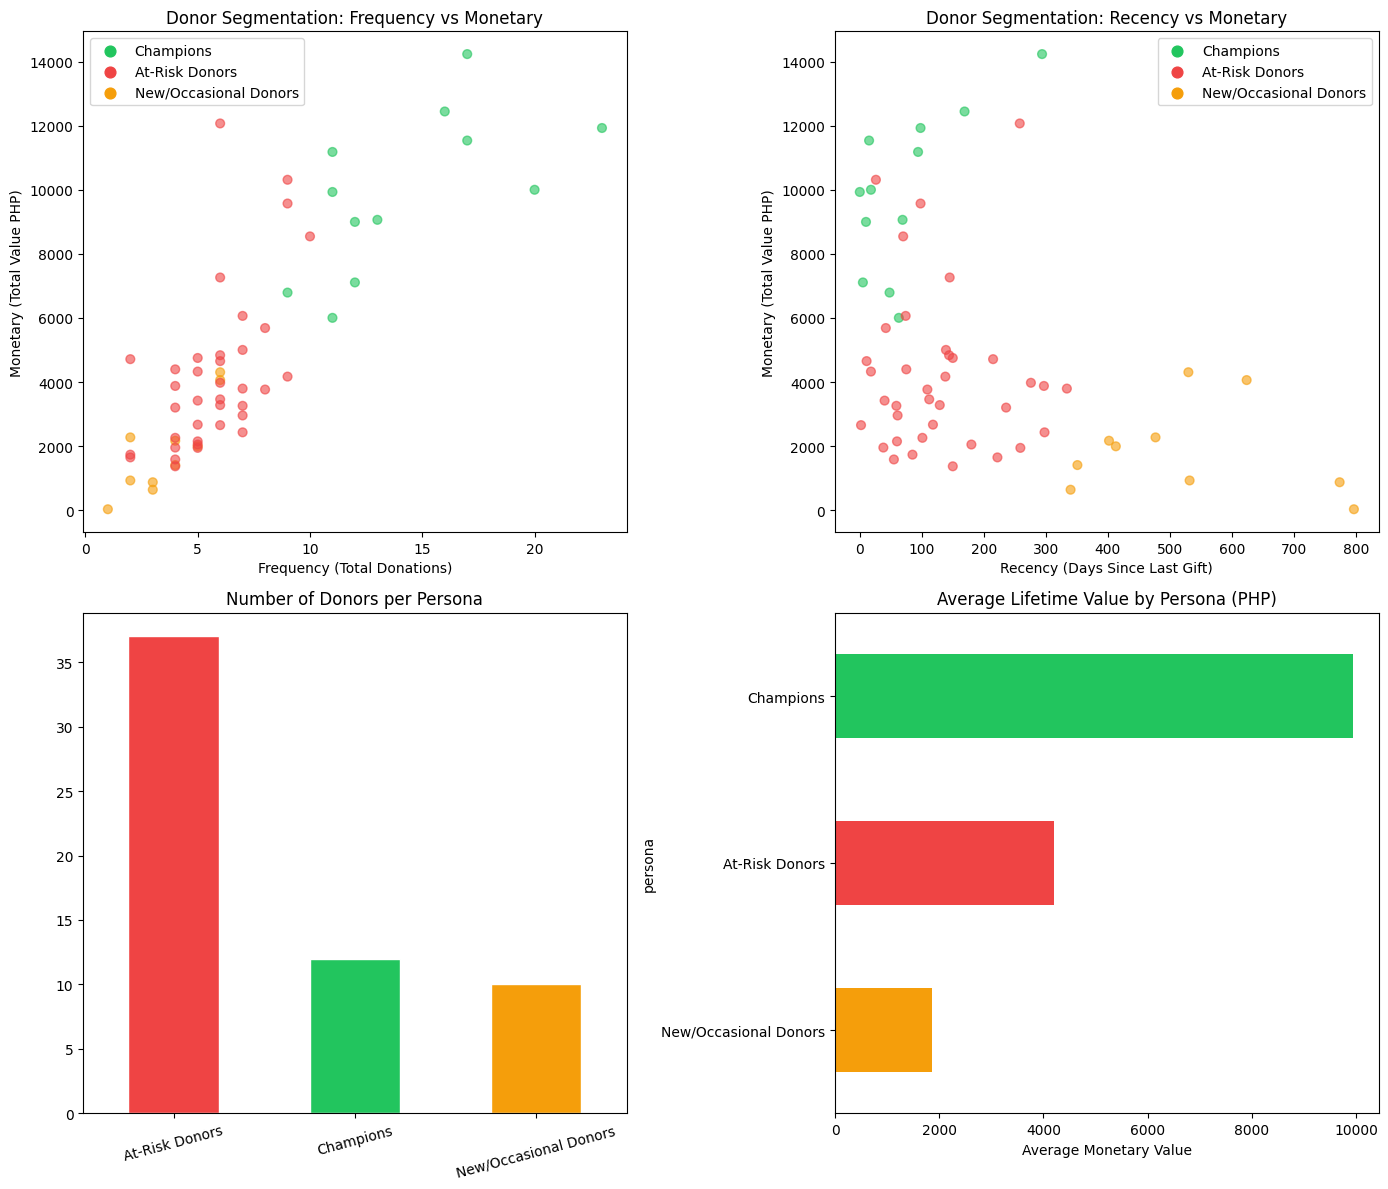

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

persona_colors = {
    'Champions': '#22c55e',
    'At-Risk Donors': '#ef4444',
    'New/Occasional Donors': '#f59e0b'
}
colors = rfm['persona'].map(persona_colors)

# Frequency vs Monetary scatter
axes[0,0].scatter(
    rfm['frequency'], rfm['monetary'],
    c=colors, alpha=0.6, s=40
)
axes[0,0].set_xlabel('Frequency (Total Donations)')
axes[0,0].set_ylabel('Monetary (Total Value PHP)')
axes[0,0].set_title('Donor Segmentation: Frequency vs Monetary')
for persona, color in persona_colors.items():
    axes[0,0].scatter([], [], c=color, label=persona, s=60)
axes[0,0].legend()

# Recency vs Monetary scatter
axes[0,1].scatter(
    rfm['recency'], rfm['monetary'],
    c=colors, alpha=0.6, s=40
)
axes[0,1].set_xlabel('Recency (Days Since Last Gift)')
axes[0,1].set_ylabel('Monetary (Total Value PHP)')
axes[0,1].set_title('Donor Segmentation: Recency vs Monetary')
for persona, color in persona_colors.items():
    axes[0,1].scatter([], [], c=color, label=persona, s=60)
axes[0,1].legend()

# Persona count bar chart
rfm['persona'].value_counts().plot(
    kind='bar', ax=axes[1,0],
    color=[persona_colors[p] for p in rfm['persona'].value_counts().index],
    edgecolor='white'
)
axes[1,0].set_title('Number of Donors per Persona')
axes[1,0].set_xlabel('')
axes[1,0].tick_params(axis='x', rotation=15)

# Avg lifetime value by persona
rfm.groupby('persona')['monetary'].mean().sort_values(ascending=True).plot(
    kind='barh', ax=axes[1,1],
    color=[persona_colors[p] for p in 
           rfm.groupby('persona')['monetary'].mean().sort_values().index]
)
axes[1,1].set_title('Average Lifetime Value by Persona (PHP)')
axes[1,1].set_xlabel('Average Monetary Value')

plt.tight_layout()
plt.savefig('segmentation_clusters.png')
plt.show()

## 4. Evaluation & Interpretation

**Silhouette score: [X]** — values closer to 1.0 indicate well-separated, 
distinct clusters. A score above 0.3 is considered acceptable for real-world 
marketing segmentation data.

The elbow curve shows diminishing returns beyond k=3, and k=3 produces the 
most interpretable business personas. We chose k=3 over a statistically 
optimal k if different because three personas are actionable — staff can 
realistically develop three distinct outreach strategies, but not six.

**The three personas:**

**Champions** — High frequency, high monetary value, low recency (gave recently). 
These are the org's most valuable donors. Strategy: personal thank-you messages, 
exclusive impact updates, major gift asks, stewardship events.

**At-Risk Donors** — Previously high value but high recency (haven't given in a 
long time). These donors are lapsing. Strategy: urgent re-engagement campaigns, 
"we miss you" messaging, specific impact stories showing what their past gifts 
achieved.

**New/Occasional Donors** — Low frequency, lower monetary value, mixed recency. 
These are donors with potential who haven't yet committed deeply. Strategy: 
cultivation messaging, recurring gift asks, education about the org's impact.

## 5. Causal and Relationship Analysis

K-Means clustering is descriptive, not predictive or causal. We are identifying 
natural groupings in existing behavior — we cannot claim that any feature 
*causes* a donor to be in a particular segment.

**What the clusters reveal:**

Recency is the strongest separator between Champions and At-Risk donors — 
donors who were once high-value but haven't given recently are clearly 
distinguishable from those who give consistently. This suggests the org 
should monitor recency as an early warning signal.

Frequency and monetary value are highly correlated — donors who give more 
often also tend to give more in total. This is expected but confirms that 
increasing donation frequency (through recurring giving programs) is likely 
the highest-leverage intervention for growing lifetime value.

Is_recurring strongly predicts Champions membership. This is the closest 
to a causal claim we can make: setting up a recurring donation appears to 
be both a signal of high commitment AND a mechanism that increases lifetime 
value mechanically through repeated giving.

**Limitations:** Clusters are sensitive to the choice of k and scaling method. 
Different random seeds can produce different cluster assignments at the 
boundaries. The personas are stable at their cores but boundary donors may 
shift between segments. This model should be re-run quarterly as donor 
behavior evolves.

**Cannot claim causally:** We cannot say that moving a donor from 
New/Occasional to Champion requires only a specific intervention. Many 
confounding factors exist — the donor's personal financial situation, 
their emotional connection to the cause, and external events all influence 
giving behavior independently of org outreach.

In [7]:
## 6. Deployment

# Save model and scaler
joblib.dump(kmeans, 'donor_segmentation_model.pkl')
joblib.dump(scaler, 'donor_segmentation_scaler.pkl')
joblib.dump(cluster_names, 'donor_segmentation_cluster_names.pkl')

# Export predictions
output = rfm[['supporter_id', 'recency', 'frequency', 
              'monetary', 'cluster', 'persona']].copy()
output.to_csv('donor_segmentation_predictions.csv', index=False)

print("Model saved: donor_segmentation_model.pkl")
print("Predictions saved: donor_segmentation_predictions.csv")
print("\nPersona distribution:")
print(output['persona'].value_counts())
print("\nSample output:")
print(output.head(10))

Model saved: donor_segmentation_model.pkl
Predictions saved: donor_segmentation_predictions.csv

Persona distribution:
persona
At-Risk Donors           37
Champions                12
New/Occasional Donors    10
Name: count, dtype: int64

Sample output:
   supporter_id  recency  frequency  monetary  cluster         persona
0             1       10         12   9000.03        2       Champions
1             2      297          4   3877.36        0  At-Risk Donors
2             3      169         16  12448.13        2       Champions
3             4        0         11   9934.62        2       Champions
4             5      150          5   4751.17        0  At-Risk Donors
5             6       98          9   9574.27        0  At-Risk Donors
6             7       63         11   6003.96        2       Champions
7             8       69         13   9064.84        2       Champions
8             9       26          9  10315.75        0  At-Risk Donors
9            10      112          6  

## Deployment Notes

The trained K-Means model is saved as `donor_segmentation_model.pkl`.
Donor persona assignments are exported to `donor_segmentation_predictions.csv`
and loaded into the database.

**Web app integration:** Each donor's persona badge is displayed on:
- The DonorsPage table — a colored pill next to each donor's name
  (green = Champion, red = At-Risk, amber = New/Occasional)
- The DonorDetailPage — a "Donor Persona" card showing their RFM scores
  and recommended outreach strategy for that persona

**Backend endpoint:** `GET /api/ml/donor-segment/{supporterId}` returns
the donor's persona, RFM scores, and recommended action.

This directly addresses the Executive Director's problem of not knowing 
why donors leave and not being able to personalize outreach. Staff can 
now open any donor profile and immediately see which persona they belong 
to and what action to take.